# The Manifold Probe: a worked example

This vignette demonstrates the `maniprobe` package on a synthetic probing dataset in
which the representation manifold is known, so that each estimate can be compared with
the truth. We construct representations of a concept in superposition with other
semantics, fit a Manifold Probe to them, and then examine the features, the manifold and
the linear readout it learns. We finish with a two-dimensional concept, and with a
comparison of the criteria for selecting the regularization parameters.

The notation follows the paper *Probing for Representation Manifolds in Superposition*
(Modell, 2026) and the package README.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from maniprobe import Probe, bs, tps, kf, ho

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
})

## 1. A probing dataset

We take the concept to be a year, $\mathcal Z = [1950, 2020]$, as for the release dates
of songs, movies and books in the paper. Its representation is a curve
$\phi : \mathcal Z \to \mathbb R^{64}$ which lies in a three-dimensional subspace, and
which is defined by three features of the year: a linear trend, and two periodic
features,

$$
\phi(z) = u_1 f_1(z) + u_2 f_2(z) + u_3 f_3(z), \qquad
f_1(z) = \sqrt 3\, t, \quad f_2(z) = \sqrt 2 \cos(\pi t), \quad f_3(z) = \sqrt 2 \cos(2 \pi t),
$$

where $t = (z - 1985)/35$ rescales the years to $[-1, 1]$. The features are mean-zero
and orthonormal when the years are uniformly distributed, which is the form of the
decomposition in Lemma 1 of the paper, and which we will use to compare the fitted
features with the truth in Section 4. Following the superposition
hypothesis, each representation is the sum of the representation of the year and a
representation $\eta(\xi)$ of some other semantics $\xi$, which we draw independently of
the year in a ten-dimensional subspace, plus a small amount of isotropic noise:

$$
x_i = \phi(z_i) + \eta(\xi_i) + \varepsilon_i.
$$

The other semantics are given more variance than the concept, so that the concept
accounts for only a small part of the variation in the representations.

In [2]:
rng = np.random.default_rng(0)
p = 64

def true_features(z):
    t = (z - 1985) / 35
    return np.column_stack(
        [np.sqrt(3) * t, np.sqrt(2) * np.cos(np.pi * t), np.sqrt(2) * np.cos(2 * np.pi * t)]
    )

Q = np.linalg.qr(rng.normal(size=(p, p)))[0]  # a random orthonormal basis of R^p
U = Q[:, :3] * [1.0, 0.8, 0.6]                 # the directions encoding the year
V = Q[:, 3:13]                                 # the directions encoding other semantics

def phi(z):
    return true_features(z) @ U.T

def simulate(n, rng):
    z = rng.uniform(1950, 2020, size=n)
    xi = rng.normal(size=(n, 10)) * np.linspace(3.0, 1.5, 10)
    X = phi(z) + xi @ V.T + 0.3 * rng.normal(size=(n, p))
    return z, X

n = 3000
z, X = simulate(n, rng)

# a 50-50 train/test split
X_train, X_test = X[: n // 2], X[n // 2 :]
z_train, z_test = z[: n // 2], z[n // 2 :]

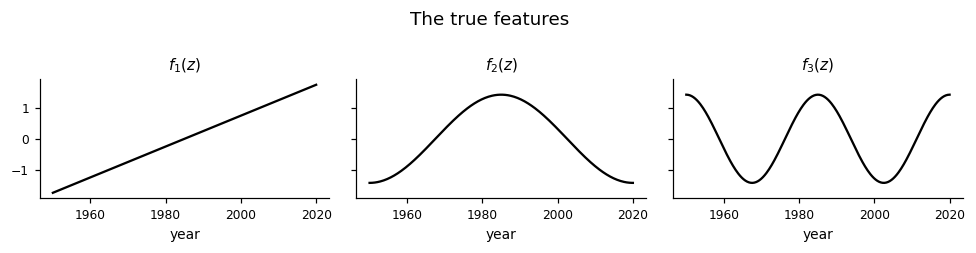

In [3]:
years = np.linspace(1950, 2020, 300)

fig, axes = plt.subplots(1, 3, figsize=(9, 2.3), sharey=True)
for k, ax in enumerate(axes):
    ax.plot(years, true_features(years)[:, k], color="k")
    ax.set_title(f"$f_{k + 1}(z)$")
    ax.set_xlabel("year")
fig.suptitle("The true features", y=0.98)
fig.tight_layout()

## 2. The concept is hidden in superposition

Since the other semantics dominate the variance of the representations, the concept is
not visible in their principal components. Below, the representations in the test set
are projected onto the first two principal components of the training set and coloured
by year, and none of the leading principal components is correlated with any of the
true features.

largest |correlation| between a leading PC and a true feature: 0.032


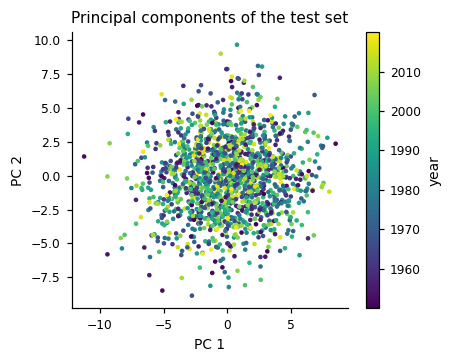

In [4]:
x_bar = X_train.mean(0)
pcs = np.linalg.svd(X_train - x_bar, full_matrices=False)[2][:3].T
scores = (X_test - x_bar) @ pcs

fig, ax = plt.subplots(figsize=(4.2, 3.4))
points = ax.scatter(scores[:, 0], scores[:, 1], c=z_test, s=4, cmap="viridis")
fig.colorbar(points, ax=ax, label="year")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_title("Principal components of the test set")
fig.tight_layout()

r = np.corrcoef(scores.T, true_features(z_test).T)[:3, 3:]
print("largest |correlation| between a leading PC and a true feature:", np.abs(r).max().round(3))

## 3. Fitting the probe

To fit the probe, we parametrize the features in a basis of 20 cubic B-splines with a
second-derivative penalty, `bs(k=20)`, and select the regularization parameters
$\lambda_w$ and $\lambda_f$ for each feature using Generalized Cross-Validation, the
default, which is described in Section 8. The test set
enters no fit. The probe reports the $R^2$ coefficient of each feature's linear
prediction on it, which measures the extent to which that feature is linearly
represented.

Since we do not know in advance how many features the representations carry, we ask for
more than we expect to find.

In [5]:
probe = Probe(X_train, z_train, bs(k=20), test_set=(X_test, z_test))
probe.fit(6)
probe.inspect()

Components fitted: 6
  Component 0   train R²  0.927463   test R²  0.915342
  Component 1   train R²  0.881294   test R²  0.867561
  Component 2   train R²  0.795195   test R²  0.786101
  Component 3   train R²  0.002635   test R² -0.000026
  Component 4   train R²  0.010974   test R² -0.003708
  Component 5   train R²  0.051409   test R² -0.030051


The first three features are well predicted from the representations, and the remaining
three are not, with test $R^2$ coefficients close to zero. The probe has therefore found
the three-dimensional subspace in which the year is represented, even though it accounts
for a small part of the variance.

The argument to `fit` is the total number of features, rather than the number to add.
To fit further features without refitting the first six, we would call
`probe.fit(8, continue_fit=True)`. Passing `verbose=True` to `Probe` reports the
progress of each fit as it runs.

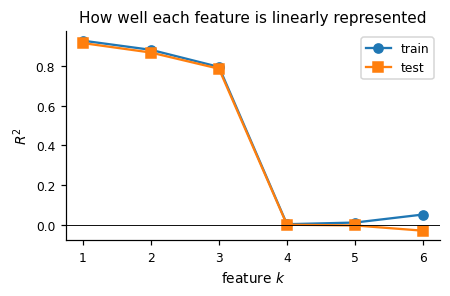

In [6]:
r2 = [c.r2 for c in probe.components]
test_r2 = [c.test_r2 for c in probe.components]
k = np.arange(1, len(r2) + 1)

fig, ax = plt.subplots(figsize=(4.2, 2.8))
ax.plot(k, r2, "o-", label="train")
ax.plot(k, test_r2, "s-", label="test")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("feature $k$")
ax.set_ylabel("$R^2$")
ax.set_title("How well each feature is linearly represented")
ax.legend()
fig.tight_layout()

## 4. The features and their linear predictions

We keep the first three features, which define a `Manifold`.

In [7]:
manifold = probe.manifold(n_components=3)
manifold.inspect()

Components: 3   frame: original
  Component 0   train R²  0.927463   test R²  0.915342
  Component 1   train R²  0.881294   test R²  0.867561
  Component 2   train R²  0.795195   test R²  0.786101


The method `f` evaluates the features $\hat f_k(z)$ at any year, and `g` evaluates their
linear predictions $g_k(x) = \hat w_k^\top x + \hat b_k$ from any representation.
Below, the top row shows the fitted features, and the bottom row shows the linear
predictions from the representations in the test set against their years, with the
fitted feature overlaid.

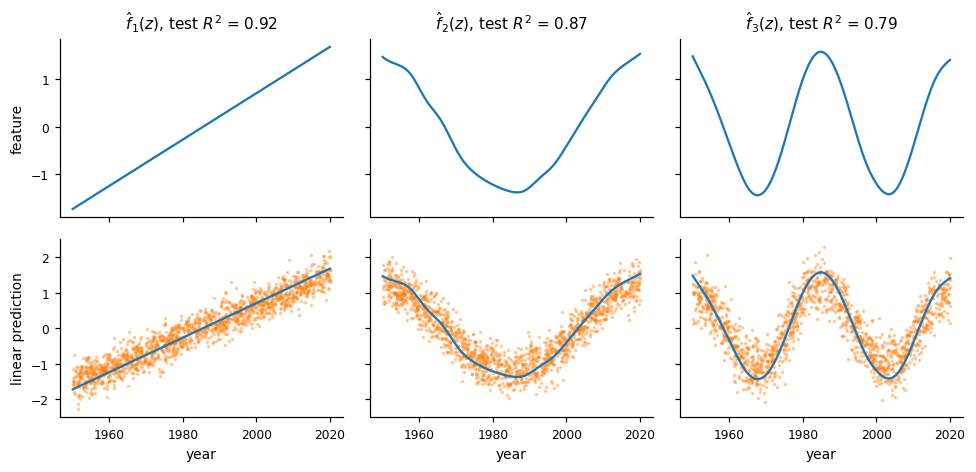

In [8]:
F_hat = manifold.f(years)
G_test = manifold.g(X_test)

fig, axes = plt.subplots(2, 3, figsize=(9, 4.4), sharex=True, sharey="row")
for k in range(3):
    axes[0, k].plot(years, F_hat[:, k], color="C0")
    axes[0, k].set_title(f"$\\hat f_{k + 1}(z)$, test $R^2$ = {manifold.test_r2[k]:.2f}")
    axes[1, k].scatter(z_test, G_test[:, k], s=2, alpha=0.3, color="C1")
    axes[1, k].plot(years, F_hat[:, k], color="C0")
    axes[1, k].set_xlabel("year")
axes[0, 0].set_ylabel("feature")
axes[1, 0].set_ylabel("linear prediction")
fig.tight_layout()

The fitted features are not the true features $f_1, f_2, f_3$. Both sets are
orthonormal, and the decomposition of $\phi$ into orthonormal features and directions is
only unique up to a rotation: replacing the features $F = [f_1, f_2, f_3]$ by $F R$ and
the directions $[u_1, u_2, u_3]$ by $[u_1, u_2, u_3] R$, for any orthogonal $R$, leaves
$\phi$ unchanged. To compare the fitted features with the truth, we first find the
rotation which best aligns them, by solving the orthogonal Procrustes problem

$$
\hat R = \underset{R^\top R = I}{\operatorname{argmin}} \; \lVert \hat F R - F \rVert_F^2,
$$

where the rows of $\hat F$ and $F$ are the fitted and true features evaluated on a grid
of years.

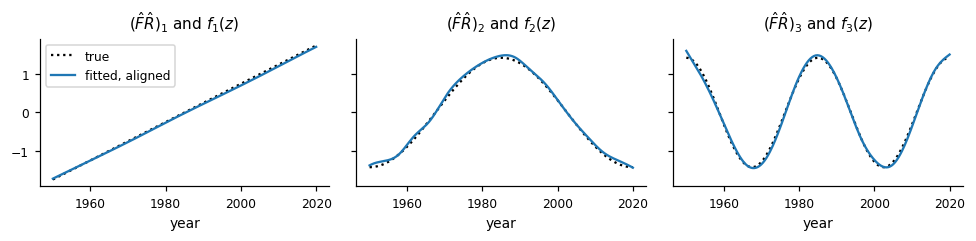

In [9]:
from scipy.linalg import orthogonal_procrustes

F_true = true_features(years)
R, _ = orthogonal_procrustes(F_hat, F_true)
F_aligned = F_hat @ R

fig, axes = plt.subplots(1, 3, figsize=(9, 2.3), sharey=True)
for k, ax in enumerate(axes):
    ax.plot(years, F_true[:, k], color="k", ls=":", label="true")
    ax.plot(years, F_aligned[:, k], color="C0", label="fitted, aligned")
    ax.set_title(f"$(\\hat F \\hat R)_{k + 1}$ and $f_{k + 1}(z)$")
    ax.set_xlabel("year")
axes[0].legend()
fig.tight_layout()

After alignment, the fitted features are close to the true features. Since the same
rotation applies to the directions, we can also compare $\hat u_1, \hat u_2, \hat u_3$
with the truth after rotating them by $\hat R$.

In [10]:
U_aligned = manifold.U @ R
print("relative error of the aligned directions:",
      (np.linalg.norm(U_aligned - U) / np.linalg.norm(U)).round(3))

relative error of the aligned directions: 0.257


The directions are recovered less precisely than the features, since each $\hat u_k$ is
a covariance estimated from 1500 representations of dimension 64, and inherits sampling
error from the other semantics.

Both errors are due to the finite sample, and should decrease as the number of samples
grows. To see this, we fit the probe to datasets of increasing size $n$, repeating each
fit on ten independent datasets. For the features, we record the root mean squared error
of the aligned features over the grid of years $z_1, \ldots, z_N$,

$$
\Big( \frac{1}{3 N} \sum_{j=1}^{N} \big\lVert \hat R^\top \hat f(z_j) - f(z_j) \big\rVert_2^2 \Big)^{1/2},
$$

and for the directions, the relative error $\lVert \hat U \hat R - U \rVert_F / \lVert U \rVert_F$
as above.

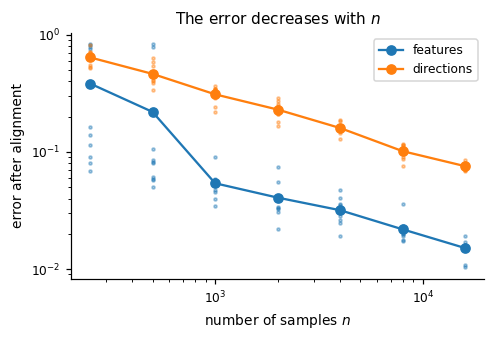

In [11]:
sizes = [250, 500, 1000, 2000, 4000, 8000, 16000]
repeats = 10
feature_errors = np.zeros((len(sizes), repeats))
direction_errors = np.zeros((len(sizes), repeats))

for i, size in enumerate(sizes):
    for r in range(repeats):
        z_r, X_r = simulate(size, np.random.default_rng(r))
        fit = Probe(X_r, z_r, bs(k=20)).fit(3).manifold()
        F_r = fit.f(years)
        R_r, _ = orthogonal_procrustes(F_r, F_true)
        feature_errors[i, r] = np.sqrt(np.mean((F_r @ R_r - F_true) ** 2))
        direction_errors[i, r] = np.linalg.norm(fit.U @ R_r - U) / np.linalg.norm(U)

fig, ax = plt.subplots(figsize=(4.6, 3.2))
for errors, label, colour in [(feature_errors, "features", "C0"),
                              (direction_errors, "directions", "C1")]:
    ax.plot(sizes, errors, "o", color=colour, ms=2, alpha=0.4)
    ax.plot(sizes, errors.mean(1), "o-", color=colour, label=label)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("number of samples $n$")
ax.set_ylabel("error after alignment")
ax.set_title("The error decreases with $n$")
ax.legend()
fig.tight_layout()

Both errors decrease steadily with $n$. For the smallest datasets, the fit misses the
third feature in some of the ten datasets, giving it an $R^2$ coefficient close to zero,
and those fits account for the points with a large feature error at $n = 250$ and
$n = 500$.

## 5. The manifold and the linear readout

The method `embed` evaluates the estimated manifold
$\hat \phi(z) = \hat u_1 \hat f_1(z) + \hat u_2 \hat f_2(z) + \hat u_3 \hat f_3(z)$, and
`project` evaluates the linear readout
$\Psi(x) = \hat u_1 g_1(x) + \hat u_2 g_2(x) + \hat u_3 g_3(x)$, which estimates the
point on the manifold from the representation alone. Both return points in
$\mathbb R^{64}$, in the centered representation space.

To draw them, we express both in an orthonormal basis of the span of
$\hat u_1, \hat u_2, \hat u_3$. On the left is the estimated manifold, with the true
manifold for comparison, and on the right are the readouts $\Psi(x)$ of the
representations in the test set, coloured by their year.

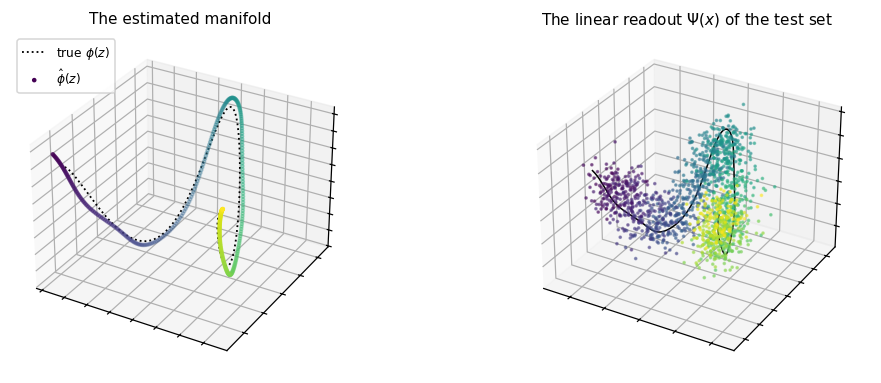

In [12]:
B = np.linalg.qr(manifold.U)[0]  # an orthonormal basis of span(u_hat)

phi_hat = manifold.embed(years) @ B
phi_true = (phi(years) - phi(z_train).mean(0)) @ B
psi = manifold.project(X_test) @ B

fig = plt.figure(figsize=(9, 4))
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot(*phi_true.T, color="k", ls=":", lw=1.2, label="true $\\phi(z)$")
ax.scatter(*phi_hat.T, c=years, cmap="viridis", s=4, label="$\\hat\\phi(z)$")
ax.set_title("The estimated manifold")
ax.legend(loc="upper left")

ax = fig.add_subplot(1, 2, 2, projection="3d")
ax.scatter(*psi.T, c=z_test, cmap="viridis", s=2, alpha=0.5)
ax.plot(*phi_hat.T, color="k", lw=1)
ax.set_title("The linear readout $\\Psi(x)$ of the test set")

for ax in fig.axes:
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_zticklabels([])
fig.subplots_adjust(left=0, right=1, wspace=0.05)

Unlike the principal components in Section 2, the linear readout orders the
representations by year along the manifold, without having been told their years.

## 6. Choosing a basis for the features

The features are produced in the order in which they were fitted, and in a basis which
is fixed only up to the constraints of the fit. `Manifold` provides four operations to
change that basis: `reorder` orders the features by their $R^2$ coefficients, `rescale`
gives unit norm to either the features or the directions, `rotate` applies a Varimax
rotation to the features, and `reset` returns to the basis as fitted.

A Varimax rotation looks for a basis in which the features are approximately sparse,
which can make them easier to interpret. Here, each rotated feature is largest in
magnitude in a different period: the 1950s, the 2010s and the 1980s respectively.

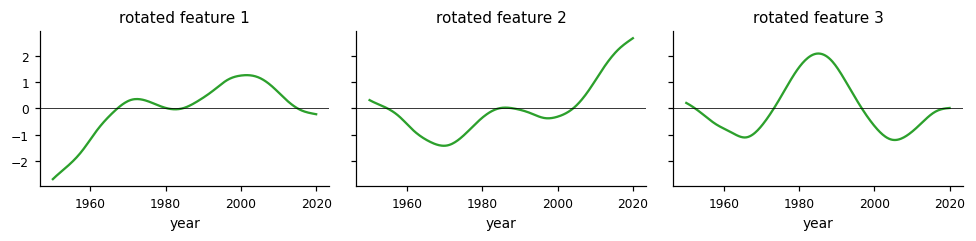

In [13]:
manifold.rotate()
F_rot = manifold.f(years)

fig, axes = plt.subplots(1, 3, figsize=(9, 2.3), sharey=True)
for k, ax in enumerate(axes):
    ax.plot(years, F_rot[:, k], color="C2")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"rotated feature {k + 1}")
    ax.set_xlabel("year")
fig.tight_layout()

The $R^2$ coefficients are recomputed in the new basis, and `inspect` reports that the
basis is no longer the one in which the features were fitted.

In [14]:
manifold.inspect()

Components: 3   frame: transformed
  Component 0   train R²  0.893075   test R²  0.879201
  Component 1   train R²  0.877861   test R²  0.869371
  Component 2   train R²  0.833015   test R²  0.818908


None of these operations changes the manifold or the linear readout. Each one is a
change of basis by a $3 \times 3$ matrix $T$, applied to the features and the directions
together,

$$
\left[ \hat f_1, \hat f_2, \hat f_3 \right] \longmapsto \left[ \hat f_1, \hat f_2, \hat f_3 \right] T,
\qquad
\left[ \hat u_1, \hat u_2, \hat u_3 \right] \longmapsto \left[ \hat u_1, \hat u_2, \hat u_3 \right] T^{-\top},
$$

so that $T$ and $T^{-\top}$ cancel in both $\hat \phi$ and $\Psi$. The operations
compose, and each returns the `Manifold`, so they can be chained.

In [15]:
manifold.reset()
before = manifold.embed(years), manifold.project(X_test)

manifold.rescale(unit="u").rotate().reorder(by="test_r2")
after = manifold.embed(years), manifold.project(X_test)

print("largest change in embed:  ", f"{np.abs(after[0] - before[0]).max():.1e}")
print("largest change in project:", f"{np.abs(after[1] - before[1]).max():.1e}")

manifold.reset();

largest change in embed:   3.3e-16
largest change in project: 8.9e-16


## 7. A two-dimensional concept

The concept values are passed to the basis unchanged, so a probe of a two-dimensional
concept differs only in its basis. We take the concept to be a location, a longitude and
latitude in the bounding box of the mainland U.S.A., as for the places in the paper, and
represent it through three features: the longitude, the latitude, and a bump centred on
one region.

In [16]:
def true_place_features(z):
    s = (z - [-95.75, 37.0]) / [29.25, 12.5]  # rescaled to [-1, 1]^2
    bump = np.exp(-((s[:, 0] - 0.3) ** 2 + (s[:, 1] + 0.2) ** 2) / 0.15)
    return np.column_stack([s[:, 0], s[:, 1], 3 * bump])

z2 = np.column_stack([rng.uniform(-125.0, -66.5, n), rng.uniform(24.5, 49.5, n)])
xi2 = rng.normal(size=(n, 10)) * np.linspace(3.0, 1.5, 10)
X2 = true_place_features(z2) @ U.T + xi2 @ V.T + 0.3 * rng.normal(size=(n, p))

X2_train, X2_test = X2[: n // 2], X2[n // 2 :]
z2_train, z2_test = z2[: n // 2], z2[n // 2 :]

A location is an isotropic concept, in the sense that distances mean the same thing in
every direction, so a thin plate spline basis is a natural choice. Since `tps` defaults
to a one-dimensional concept, we pass `d=2`. A tensor product of B-splines, such as
`bs(k=(10, 10))`, would also work, and would be the better choice if the two coordinates
were in unrelated units.

In [17]:
place_probe = Probe(X2_train, z2_train, tps(k=60, d=2), test_set=(X2_test, z2_test))
place_probe.fit(5)
place_probe.inspect()

Components fitted: 5
  Component 0   train R²  0.723297   test R²  0.709975
  Component 1   train R²  0.799399   test R²  0.780887
  Component 2   train R²  0.608121   test R²  0.520613
  Component 3   train R²  0.073537   test R² -0.039359
  Component 4   train R²  0.025473   test R² -0.013378


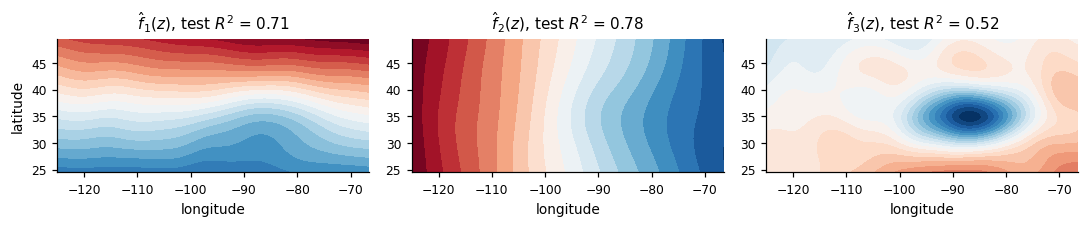

In [18]:
lon, lat = np.meshgrid(np.linspace(-125.0, -66.5, 120), np.linspace(24.5, 49.5, 60))
grid = np.column_stack([lon.ravel(), lat.ravel()])
place_manifold = place_probe.manifold(n_components=3)
F2_hat = place_manifold.f(grid)

fig, axes = plt.subplots(1, 3, figsize=(10, 2.4))
for k, ax in enumerate(axes):
    level = np.abs(F2_hat[:, k]).max()
    image = ax.contourf(lon, lat, F2_hat[:, k].reshape(lon.shape), levels=20,
                        cmap="RdBu_r", vmin=-level, vmax=level)
    ax.set_title(f"$\\hat f_{k + 1}(z)$, test $R^2$ = {place_manifold.test_r2[k]:.2f}")
    ax.set_xlabel("longitude")
    ax.set_aspect("equal")
axes[0].set_ylabel("latitude")
fig.tight_layout()

These true features are not orthonormal, so a rotation cannot align the fitted features
with them. Instead, we check that the fitted features span the same space, by measuring
the fraction of each true feature which lies in the span of the fitted features.

In [19]:
def captured(target, basis):
    # the fraction of each column of `target` lying in the column span of `basis`
    projected = basis @ np.linalg.lstsq(basis, target, rcond=None)[0]
    return np.linalg.norm(projected, axis=0) / np.linalg.norm(target, axis=0)

F2_true = true_place_features(z2_train) - true_place_features(z2_train).mean(0)
print("true features captured by span(f_hat):", captured(F2_true, place_manifold.f()).round(4))

true features captured by span(f_hat): [0.9994 0.9972 0.9866]


## 8. Selecting the regularization parameters

Each feature has two regularization parameters, which the `criterion` argument of
`Probe` selects. By default, the probe is fitted by alternating least squares, and
Generalized Cross-Validation, `gcv()`, is applied to each of the two ridge regressions
at every iteration. This is cheap. The alternatives `reml()`, `aic()` and `bic()` are
applied in the same way.

The criteria `kf()` and `ho()` instead score the joint objective on held-out data, using
$k$-fold cross-validation or a single train/validation split respectively, and search
over the regularization parameters with Bayesian optimization by default. Below, we fit
three features to the year dataset with each, and compare the test $R^2$ coefficients
and the time taken with the default.

In [20]:
import time

criteria = {
    "default": None,
    "kf(k=5)": kf(k=5, seed=0),
    "ho(train=0.8)": ho(train=0.8, seed=0),
}

for name, criterion in criteria.items():
    start = time.perf_counter()
    fit = Probe(X_train, z_train, bs(k=20), criterion=criterion,
                test_set=(X_test, z_test)).fit(3)
    seconds = time.perf_counter() - start
    scores = "  ".join(f"{c.test_r2:.4f}" for c in fit.components)
    print(f"{name:>14}   test R^2: {scores}   ({seconds:.2f}s)")

       default   test R^2: 0.9153  0.8676  0.7861   (0.02s)


       kf(k=5)   test R^2: 0.9152  0.8659  0.7861   (0.23s)
 ho(train=0.8)   test R^2: 0.9150  0.8665  0.7786   (0.17s)


On this dataset the three agree closely, and cross-validation is considerably slower.
This is the usual situation, and for general use we recommend the default.